# 4.05 New LOM and Two Coupled Transmon Example with sequence

> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) for a complete runnable walkthrough and [`docs/headless-usage.rst`](https://qiskit-community.github.io/qiskit-metal/headless-usage.html) for the full reference.

> 🧭 **Other simulation pathways.** This notebook uses Ansys, which needs a license. Without one, the same kind of result can come from the open-source ElmerFEM path for capacitance (tutorial 4.19) or the pip-installable gmsh + scikit-fem solver for eigenmodes, couplings and capacitance (tutorials 4.43–4.45); AWS Palace is available through SQDMetal, with a native integration in progress. [Simulation pathways](https://qiskit-community.github.io/qiskit-metal/simulation-pathways.html) summarizes what each solver computes, how to install it, and which tutorials use it.

> 📦 **What you need.** The first half (the LOM analysis, from the stored Q3D capacitance matrices) needs only Quantum Metal. The second half uses the third-party [Sequencing](https://sequencing.readthedocs.io) package, which Quantum Metal does not install: `pip install sequencing`. Its latest release (1.2.0) is written for qutip 4; when `lom_time_evolution_sim` is imported, Quantum Metal adapts Sequencing's solver calls to the qutip 5 it requires, so the whole notebook runs. The time evolution runs in about 5 minutes.

In [1]:
import numpy as np

from qiskit_metal.analyses.quantization.lumped_capacitive import (
    load_q3d_capacitance_matrix,
)
from qiskit_metal.analyses.quantization.lom_core_analysis import (
    CompositeSystem,
    Cell,
    Subsystem,
)

from scipy.constants import speed_of_light as c_light

import matplotlib.pyplot as plt

## Example: two transmons coupled by a direct coupler
this part is identical to tutorial 4.05; please reference it for more detailed comments

### load transmon cell Q3d simulation results

In [2]:
path1 = "./Q1_TwoTransmon_CapMatrix.txt"
ta_mat, _, _, _ = load_q3d_capacitance_matrix(path1)

Imported capacitance matrix with UNITS: [fF] now converted to USER UNITS:[fF]                 from file:
	./Q1_TwoTransmon_CapMatrix.txt


,coupler_connector_pad_Q1,ground_main_plane,pad_bot_Q1,pad_top_Q1,readout_connector_pad_Q1
coupler_connector_pad_Q1,59.20,-37.28,-2.01,-19.11,-0.23
ground_main_plane,-37.28,246.33,-39.79,-39.86,-37.30
pad_bot_Q1,-2.01,-39.79,93.05,-30.61,-19.22
pad_top_Q1,-19.11,-39.86,-30.61,92.99,-2.01
readout_connector_pad_Q1,-0.23,-37.30,-19.22,-2.01,59.33


In [3]:
path2 = "./Q2_TwoTransmon_CapMatrix.txt"
tb_mat, _, _, _ = load_q3d_capacitance_matrix(path2)

Imported capacitance matrix with UNITS: [fF] now converted to USER UNITS:[fF]                 from file:
	./Q2_TwoTransmon_CapMatrix.txt


,coupler_connector_pad_Q2,ground_main_plane,pad_bot_Q2,pad_top_Q2,readout_connector_pad_Q2
coupler_connector_pad_Q2,64.52,-38.63,-2.18,-22.93,-0.22
ground_main_plane,-38.63,267.40,-49.28,-49.30,-38.67
pad_bot_Q2,-2.18,-49.28,121.38,-45.24,-23.06
pad_top_Q2,-22.93,-49.30,-45.24,121.24,-2.18
readout_connector_pad_Q2,-0.22,-38.67,-23.06,-2.18,64.70


### Create LOM cells from capacitance matrices

In [4]:
# cell 1: transmon Alice cell

opt1 = dict(
    node_rename={
        "coupler_connector_pad_Q1": "coupling",
        "readout_connector_pad_Q1": "readout_alice",
    },
    cap_mat=ta_mat,
    ind_dict={("pad_top_Q1", "pad_bot_Q1"): 10},  # junction inductance in nH
    jj_dict={("pad_top_Q1", "pad_bot_Q1"): "j1"},
    cj_dict={("pad_top_Q1", "pad_bot_Q1"): 2},  # junction capacitance in fF
)
cell_1 = Cell(opt1)


# cell 2: transmon Bob cell
opt2 = dict(
    node_rename={
        "coupler_connector_pad_Q2": "coupling",
        "readout_connector_pad_Q2": "readout_bob",
    },
    cap_mat=tb_mat,
    ind_dict={("pad_top_Q2", "pad_bot_Q2"): 12},  # junction inductance in nH
    jj_dict={("pad_top_Q2", "pad_bot_Q2"): "j2"},
    cj_dict={("pad_top_Q2", "pad_bot_Q2"): 2},  # junction capacitance in fF
)
cell_2 = Cell(opt2)

### Make subsystems

In [5]:
# subsystem 1: transmon Alice
transmon_alice = Subsystem(name="transmon_alice", sys_type="TRANSMON", nodes=["j1"])


# subsystem 2: transmon Bob
transmon_bob = Subsystem(name="transmon_bob", sys_type="TRANSMON", nodes=["j2"])


# subsystem 3: Alice readout resonator
q_opts = dict(
    f_res=8,  # resonator dressed frequency in GHz
    Z0=50,  # characteristic impedance in Ohm
    vp=0.404314 * c_light,  # phase velocity
)
res_alice = Subsystem(
    name="readout_alice",
    sys_type="TL_RESONATOR",
    nodes=["readout_alice"],
    q_opts=q_opts,
)


# subsystem 4: Bob readout resonator
q_opts = dict(
    f_res=7.6,  # resonator dressed frequency in GHz
    Z0=50,  # characteristic impedance in Ohm
    vp=0.404314 * c_light,  # phase velocity
)
res_bob = Subsystem(
    name="readout_bob", sys_type="TL_RESONATOR", nodes=["readout_bob"], q_opts=q_opts
)

### Creat the composite system from the cells and the subsystems

In [6]:
composite_sys = CompositeSystem(
    subsystems=[transmon_alice, transmon_bob, res_alice, res_bob],
    cells=[cell_1, cell_2],
    grd_node="ground_main_plane",
    nodes_force_keep=["readout_alice", "readout_bob"],
)

In [7]:
cg = composite_sys.circuitGraph()
print(cg)

node_jj_basis:
-------------

['j1', 'pad_bot_Q1', 'j2', 'pad_bot_Q2', 'readout_alice', 'readout_bob', 'coupling']

nodes_keep:
-------------

['j1', 'j2', 'readout_alice', 'readout_bob']

L_inv_k (reduced inverse inductance matrix):
-------------

                j1        j2  readout_alice  readout_bob
j1             0.1  0.000000            0.0          0.0
j2             0.0  0.083333            0.0          0.0
readout_alice  0.0  0.000000            0.0          0.0
readout_bob    0.0  0.000000            0.0          0.0

C_k (reduced capacitance matrix):
-------------

                      j1         j2  readout_alice  readout_bob
j1             63.185549  -0.766012       8.318893    -0.323188
j2             -0.766012  84.343548      -0.342145    10.039921
readout_alice   8.318893  -0.342145      55.591197    -0.144354
readout_bob    -0.323188  10.039921      -0.144354    60.347427



### Generate the hilberspace from the composite system, leveraging the scqubits package

In [8]:
hilbertspace = composite_sys.create_hilbertspace()
hilbertspace = composite_sys.add_interaction()
hilbertspace.hamiltonian()

Quantum object: dims=[[10, 10, 5, 5], [10, 10, 5, 5]], shape=(2500, 2500), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-24384.00875812+0.00000000e+00j      0.        +1.08232556e-01j
       0.        +0.00000000e+00j ...      0.        +0.00000000e+00j
       0.        +0.00000000e+00j      0.        +0.00000000e+00j]
 [     0.        -1.08232556e-01j -16784.00875812+0.00000000e+00j
       0.        +1.53063948e-01j ...      0.        +0.00000000e+00j
       0.        +0.00000000e+00j      0.        +0.00000000e+00j]
 [     0.        +0.00000000e+00j      0.        -1.53063948e-01j
   -9184.00875812+0.00000000e+00j ...      0.        +0.00000000e+00j
       0.        +0.00000000e+00j      0.        +0.00000000e+00j]
 ...
 [     0.        +0.00000000e+00j      0.        +0.00000000e+00j
       0.        +0.00000000e+00j ... 104469.11377066+0.00000000e+00j
       0.        +8.65346690e+02j      0.        +0.00000000e+00j]
 [     0.        +0.00000000e+00j      0.        +0.00000000

### Print the results

In [9]:
hamiltonian_results = composite_sys.hamiltonian_results(hilbertspace, evals_count=30)


system frequencies in GHz:
--------------------------
{'transmon_alice': np.float64(6.053360674265853), 'transmon_bob': np.float64(4.798988315982038), 'readout_alice': np.float64(8.009053131548402), 'readout_bob': np.float64(7.604410557915028)}

Chi matrices in MHz
--------------------------
                transmon_alice  transmon_bob  readout_alice  readout_bob
transmon_alice     -353.239969     -0.542896      -4.199825    -0.003128
transmon_bob         -0.542896   -263.940135      -0.001215    -1.487832
readout_alice        -4.199825     -0.001215      -0.015910    -0.000019
readout_bob          -0.003128     -1.487832      -0.000019    -0.002378


In [10]:
hamiltonian_results["chi_in_MHz"].to_dataframe()

,transmon_alice,transmon_bob,readout_alice,readout_bob
transmon_alice,-353.239969,-0.542896,-4.199825,-0.003128
transmon_bob,-0.542896,-263.940135,-0.001215,-1.487832
readout_alice,-4.199825,-0.001215,-0.015910,-0.000019
readout_bob,-0.003128,-1.487832,-0.000019,-0.002378


In [11]:
composite_sys.compute_gs()

                       j1          j2  readout_alice  readout_bob
j1               0.000000   20.115409    -129.897533     3.275638
j2              20.115409    0.000000       2.678608  -111.508227
readout_alice -129.897533    2.678608       0.000000     0.436190
readout_bob      3.275638 -111.508227       0.436190     0.000000

In [12]:
transmon_alice.h_params

defaultdict(dict,
            {'j1': {'EJ': np.float64(16346.151155765461),
              'EC': np.float64(312.7568711203924),
              'Q_zpf': 3.20435314e-19,
              'default_charge_op': Operator(op=array([[-22,   0,   0, ...,   0,   0,   0],
                     [  0, -21,   0, ...,   0,   0,   0],
                     [  0,   0, -20, ...,   0,   0,   0],
                     ...,
                     [  0,   0,   0, ...,  20,   0,   0],
                     [  0,   0,   0, ...,   0,  21,   0],
                     [  0,   0,   0, ...,   0,   0,  22]], shape=(45, 45)), add_hc=False)}})

In [13]:
transmon_bob.h_params

defaultdict(dict,
            {'j2': {'EJ': np.float64(13621.79262980455),
              'EC': np.float64(234.32409449031465),
              'Q_zpf': 3.20435314e-19,
              'default_charge_op': Operator(op=array([[-22,   0,   0, ...,   0,   0,   0],
                     [  0, -21,   0, ...,   0,   0,   0],
                     [  0,   0, -20, ...,   0,   0,   0],
                     ...,
                     [  0,   0,   0, ...,  20,   0,   0],
                     [  0,   0,   0, ...,   0,  21,   0],
                     [  0,   0,   0, ...,   0,   0,  22]], shape=(45, 45)), add_hc=False)}})

### ***********

## Time evolution simulation with Sequencing https://sequencing.readthedocs.io/en/latest/index.html

In [14]:
%config InlineBackend.figure_formats = ['svg']

import qutip
from tqdm import tqdm

from sequencing import get_sequence, sync
from sequencing.calibration import tune_rabi

from qiskit_metal.analyses.quantization.lom_time_evolution_sim import (
    lom_composite_sys_to_seq_sys,
)

### A simple example: selective qubit pulse in the strong dispersive regime

*(Illustration `number_splitting.png` not in repo — see [Schuster thesis](https://rsl.yale.edu/sites/default/files/files/RSL_Theses/SchusterThesis.pdf) for the original figure.)*

\* *Dave Schuster's thesis* https://rsl.yale.edu/sites/default/files/files/RSL_Theses/SchusterThesis.pdf

## LOM composite system to Sequencing system

*(Illustration `sequencing_h.png` not in repo — see the [Sequencing documentation](https://sequencing.readthedocs.io/en/latest/notebooks/introduction.html) for the original figure.)*

\* Sequencing documentation, https://sequencing.readthedocs.io/en/latest/notebooks/introduction.html

In this part of the demo, we essentially **reproduce the exact same example as demonstrated in the Sequencing tutorial**, "Controlling a Transmon coupled to Cavity", https://sequencing.readthedocs.io/en/latest/notebooks/06-transmon-cavity-control.html, by generating a Sequencing system converted from a LOM composite system. Hence please follow the Sequencing tutorial for more detailed explanations on the pulse construction, calibration and ultimately simulation.

### Convert Metal LOM system to Sequencing system
A Qiskit Metal LOM subsystem corresponds to a 'mode' in Sequencing system. The diagonal elements in `hamiltonian_results['chi_in_MHz']` (anharmonicity) are the self-Kerr's and the off-diagonal elements the cross-Kerr's in Sequencing's Hamiltonian screenshot above.

For more details on modes in Sequencing system, please check out the Sequencing package's documentation. The `levels` parameter specifies the number of energy levels to keep for each mode in the Sequencing system. If not specified, i.e., None, they default to LOM subsystem's respective dimensions as represented by the LOM composite system's hilberspace (`hilbertspace.subsystem_dims`)

In [15]:
system = lom_composite_sys_to_seq_sys(
    composite_sys, hilbertspace, levels=[3, 3, 10, 10]
)

In [16]:
alice = system.modes[1]
readout_alice = system.modes[-1]
print(alice)
print(readout_alice)

Transmon(name='transmon_alice', cls='sequencing.modes.Transmon', levels=3, t1=inf, t2=inf, thermal_population=0.0, df=0.0, kerr=-0.3532399685176006, pulses={'smoothed_constant_pulse': SmoothedConstantPulse(name='smoothed_constant_pulse', cls='sequencing.pulses.SmoothedConstantPulse', amp=1.0, detune=0.0, phase=0.0, dt=1, noise_sigma=0.0, noise_alpha=0.0, scale_noise=False, length=100, sigma=0, shape='tanh'), 'gaussian_pulse': GaussianPulse(name='gaussian_pulse', cls='sequencing.pulses.GaussianPulse', amp=1.0, detune=0.0, phase=0.0, dt=1, noise_sigma=0.0, noise_alpha=0.0, scale_noise=False, sigma=10, chop=4, drag=0.0)}, default_pulse='gaussian_pulse')
Cavity(name='readout_alice', cls='sequencing.modes.Cavity', levels=10, t1=inf, t2=inf, thermal_population=0.0, df=0.0, kerr=-1.5909784968243912e-05, pulses={'smoothed_constant_pulse': SmoothedConstantPulse(name='smoothed_constant_pulse', cls='sequencing.pulses.SmoothedConstantPulse', amp=1.0, detune=0.0, phase=0.0, dt=1, noise_sigma=0.0, n

### Are there zero photon in the cavity?

## Tune the amplitude of a pulse on Alice using an amplitude-Rabi sequence

100%|██████████| 51/51 [00:01<00:00, 42.37it/s]


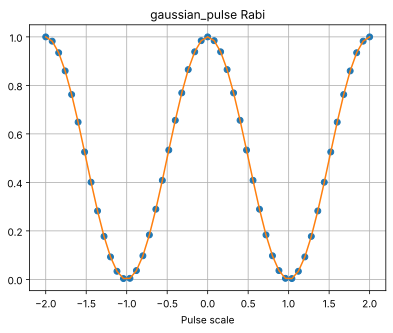

In [17]:
selective_sigma = 100  # ns

# tune selective qubit pulse using Rabi
with system.use_modes([alice]):
    with alice.temporarily_set(gaussian_pulse__sigma=selective_sigma):
        _, _, selective_qubit_amp = tune_rabi(
            system,
            system.fock(
                transmon_alice=0, transmon_bob=0, readout_alice=0, readout_bob=0
            ),
            mode_name=alice.name,
            update=False,
            plot=True,
            verify=False,
        )

In [18]:
def selective_rotation(qubit, angle, phase=0, detune=0, sigma=selective_sigma):
    with qubit.gaussian_pulse.temporarily_set(sigma=sigma, amp=selective_qubit_amp):
        qubit.rotate(np.pi, phase, detune=detune)

## Populate alice readout cavity with 0, 1, 2, 3 photons respectively

In [19]:
init_states = [
    (f"$|g{n}\\rangle$", system.fock(transmon_alice=0, readout_alice=n))
    for n in range(4)
]

In [20]:
# Apply a selective pi pulse that is resonant
# with the qubit when the cavity is in |0>.
results = {}

seq = get_sequence(system)
selective_rotation(alice, np.pi)

for label, state in tqdm(init_states, desc="Initial states"):
    result = seq.run(state)
    results[label] = result

Initial states: 100%|██████████| 4/4 [00:00<00:00,  6.19it/s]


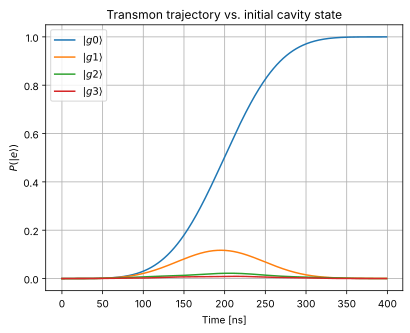

In [21]:
fig, ax = plt.subplots(1, 1)
for label, result in results.items():
    # trace over the cavity
    qubit_states = [state.ptrace(alice.index) for state in result.states]
    e_pops = qutip.expect(alice.fock_dm(1, full_space=False), qubit_states)
    ax.plot(result.times, e_pops, label=label)
    ax.grid(True)
    ax.legend(loc=0)
ax.set_xlabel("Time [ns]")
ax.set_ylabel(r"$P(|e\rangle)$")
_ = ax.set_title("Transmon trajectory vs. initial cavity state")

## Use the qubit to measure the cavity: how many photons are there?

In [22]:
def rotate_qubit_on_n(
    system, n, angle, qubit_name="transmon_alice", cavity_name="readout_alice"
):
    """Rotate the qubit state iff the cavity is in state |n> by detuning
    the selective qubit pulse by n * chi.
    """
    qubit = system.get_mode(qubit_name)
    cavity = system.get_mode(cavity_name)
    chi = system.cross_kerrs[frozenset([qubit.name, cavity.name])]
    selective_rotation(qubit, angle, detune=n * chi)

### Displace the cavity and then apply selective pulse on alice

In [23]:
max_n = 4

init_state = system.ground_state()
# qubit in |e> after selective pi pulse means cavity in |n>
e_op = alice.fock_dm(1, full_space=False)
disp_amps = np.linspace(0.01, 3, 21)
e_pops = []

for n in range(max_n):
    e_pops.append([])
    for amp in tqdm(disp_amps, desc=f"Disp. amp. (measure n={n})"):
        seq = get_sequence(system)

        readout_alice.displace(amp)
        sync()
        rotate_qubit_on_n(system, n, np.pi)
        result = seq.run(init_state)
        # trace over the cavity
        transmon_state = result.states[-1].ptrace(alice.index)
        e_pops[-1].append(qutip.expect(e_op, transmon_state))

Disp. amp. (measure n=3): 100%|██████████| 21/21 [00:04<00:00,  4.64it/s]


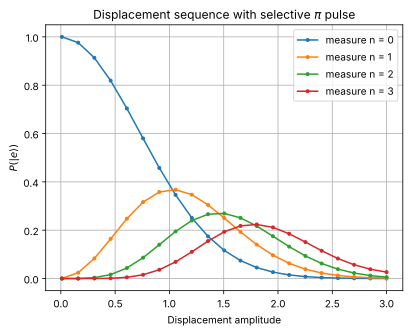

In [24]:
fig, ax = plt.subplots()
for n, es in enumerate(e_pops):
    ax.plot(disp_amps, es, ".-", label=f"measure n = {n}")
ax.legend(loc=0)
ax.grid(True)
ax.set_xlabel("Displacement amplitude")
ax.set_ylabel(r"$P(|e\rangle)$")
_ = ax.set_title(r"Displacement sequence with selective $\pi$ pulse")